
# Continuous Distributions (Uniform, Normal, Exponential) — Lecture + Exercises

**Colab-ready notebook**, generated on 2025-09-17 09:59 (local).  
Only **NumPy**, **SciPy** (`scipy.stats`), and **Matplotlib** are used. No custom helper functions.

> Tip: Run cells top-to-bottom. SciPy is preinstalled in Colab.


In [2]:

# @title Imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
np.set_printoptions(precision=6, suppress=True)



## 1) Uniform Distribution — theory

For a continuous uniform random variable $$X \sim \mathrm{Unif}[a,b]$$:
- **PDF**: $$ f(x) = \begin{cases}
\dfrac{1}{b-a}, & a \le x \le b \\[4pt]
0, & \text{otherwise}
\end{cases} $$

- **CDF**: $$ F(x) = \begin{cases}
0, & x < a \\[4pt]
\dfrac{x-a}{b-a}, & a \le x \le b \\[6pt]
1, & x > b
\end{cases} $$

- **Mean**: $$\mathbb{E}[X] = \dfrac{a+b}{2}$$

- **Variance**: $$\mathrm{Var}(X) = \dfrac{(b-a)^2}{12}$$


**Tasks**

Using stats.uniform and the function pdf and cdf, please
plot the CDF and PDF

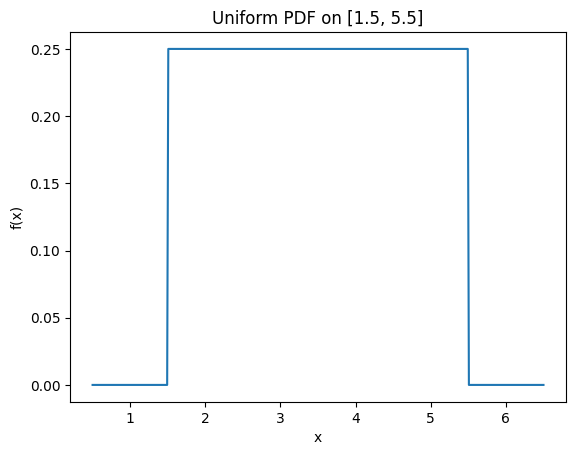

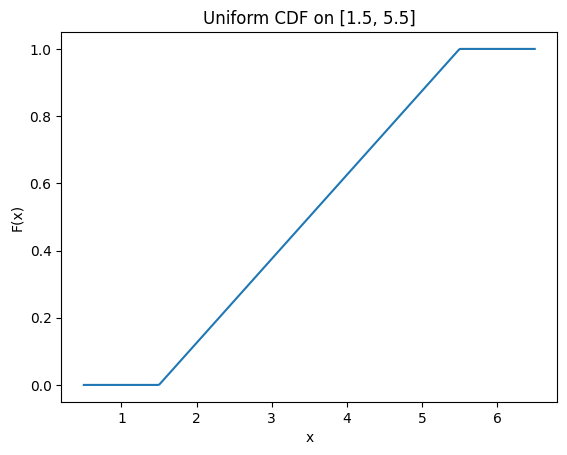

In [3]:
a, b = 1.5, 5.5
xs = np.linspace(a-1, b+1, 400)
rv = stats.uniform(loc=a, scale=b-a)

plt.figure()
plt.plot(xs, rv.pdf(xs))
plt.title("Uniform PDF on [1.5, 5.5]")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.show()

plt.figure()
plt.plot(xs, rv.cdf(xs))
plt.title("Uniform CDF on [1.5, 5.5]")
plt.xlabel("x"); plt.ylabel("F(x)")
plt.show()



### Exercise — Uniform on $[1.5, 5.5]$

Suppose $$X \sim \mathrm{Unif}[1.5, 5.5]$$.

(a) Determine the **mean, variance, and standard deviation** of \(X\).  
(b) Compute $$\mathbb{P}(X < 2.5)$$.  
(c) Determine the **CDF** $$F_X(x)$$.

Then, **simulate** many draws from this distribution and compare the empirical results to the theoretical ones.




In [5]:

a, b = 1.5, 5.5
mean = (a + b) / 2.0
var = (b - a)**2 / 12.0
std = np.sqrt(var)
p_less_2_5 = (2.5 - a) / (b - a)

print(f"(a) mean = {mean:.4f}, variance = {var:.4f}, std = {std:.4f}")
print(f"(b) P(X < 2.5) = {(p_less_2_5):.4f}")
print("\n(c) CDF: F(x)=0 for x<1.5; (x-1.5)/4 for 1.5<=x<=5.5; 1 for x>5.5")


(a) mean = 3.5000, variance = 1.3333, std = 1.1547
(b) P(X < 2.5) = 0.2500

(c) CDF: F(x)=0 for x<1.5; (x-1.5)/4 for 1.5<=x<=5.5; 1 for x>5.5


Empirical vs Theoretical
Mean:      3.50357  |  3.50000
Std dev:   1.15549  |  1.15470
P(X<2.5):  0.25000  |  0.25000


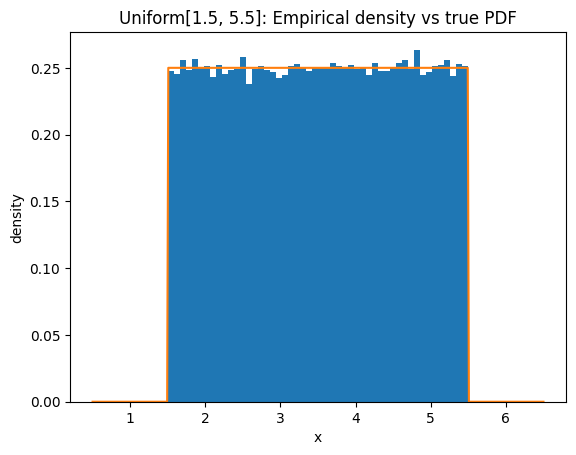

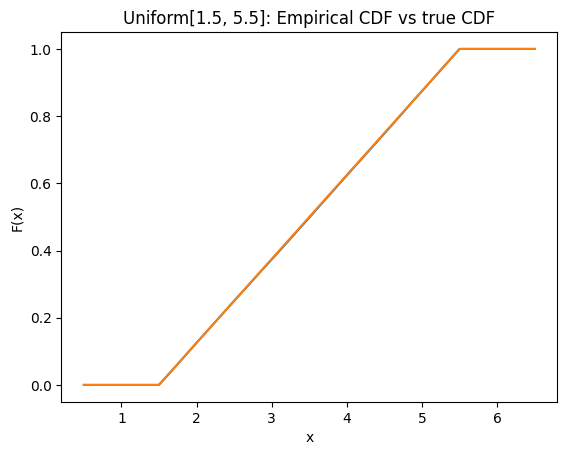

In [8]:
#Empirical values

a, b = 1.5, 5.5
N = 200_000  # try larger/smaller values to see convergence

# Create a sample of N points from this distribution (rvs)
samples = stats.uniform.rvs(loc=a, scale=b-a, size=N, random_state=0)


# Empirical estimates
mean_hat = samples.mean()
var_hat  = samples.var(ddof=0)  # population variance
std_hat  = samples.std(ddof=0)
p_lt_2_5_hat = (samples < 2.5).mean()


print("Empirical vs Theoretical")
print(f"Mean:      {mean_hat:.5f}  |  {mean:.5f}")
print(f"Std dev:   {std_hat:.5f}  |  {std:.5f}")
print(f"P(X<2.5):  {p_lt_2_5_hat:.5f}  |  {p_less_2_5:.5f}")

# PDF comparison (histogram vs true PDF)
rv = stats.uniform(loc=a, scale=b-a)
xs = np.linspace(a-1, b+1, 400)

plt.figure()
plt.hist(samples, bins=50, density=True)
plt.plot(xs, rv.pdf(xs))
plt.title("Uniform[1.5, 5.5]: Empirical density vs true PDF")
plt.xlabel("x"); plt.ylabel("density")
plt.show()

# Empirical CDF vs true CDF
xs_grid = np.linspace(a-1, b+1, 500)
sorted_samp = np.sort(samples)
# empirical CDF at grid points: proportion of samples <= x
ecdf = np.searchsorted(sorted_samp, xs_grid, side="right") / N

plt.figure()
plt.plot(xs_grid, ecdf)
plt.plot(xs_grid, rv.cdf(xs_grid))
plt.title("Uniform[1.5, 5.5]: Empirical CDF vs true CDF")
plt.xlabel("x"); plt.ylabel("F(x)")
plt.show()



## Worked Example — Packaged Herbicide

The PDF of the net weight \(X\) (in pounds) is \( f(x) = 2 \) for \( 49.75 < x < 50.25 \) (0 otherwise).  
This is uniform on \(49.75, 50.25\).

**(a)** Determine $$\mathbb{P}(X > 50)$$.  
**(b)** How much chemical is contained in 90% of all packages?


In [10]:

a, b = 49.75, 50.25
distri = stats.uniform(loc=a, scale=b-a)

p_greater_50 = 1.0 - distri.cdf(50.0)
x90 = distri.ppf(0.90)  # ≤ this in 90% of packages

print(f"(a) P(X > 50) = {p_greater_50:.4f}")
print(f"(b)    90th percentile (≤ this in 90%): {x90:.2f}")


(a) P(X > 50) = 0.5000
(b)    90th percentile (≤ this in 90%): 50.20 lb



## 2) Exponential Distribution — theory

If $$X \sim \mathrm{Exp}(\lambda)$$ with rate $$\lambda>0$$ and mean $$1/\lambda$$
- **PDF**: $$ f(x) = \lambda e^{-\lambda x}, \quad x \ge 0 $$
- **CDF**: $$ F(x) = 1 - e^{-\lambda x}, \quad x \ge 0 $$
- **Mean**: $$ \mathbb{E}[X] = \dfrac{1}{\lambda} $$
- **Variance**: $$ \mathrm{Var}(X) = \dfrac{1}{\lambda^2} $$




**Tasks**

Using stats.exponential and the function pdf and cdf, please
plot the CDF and PDF


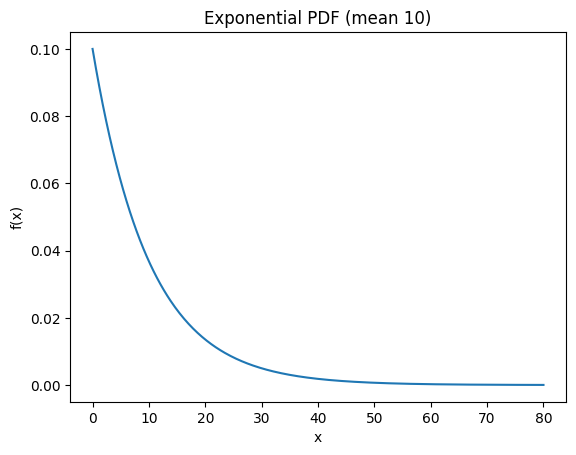

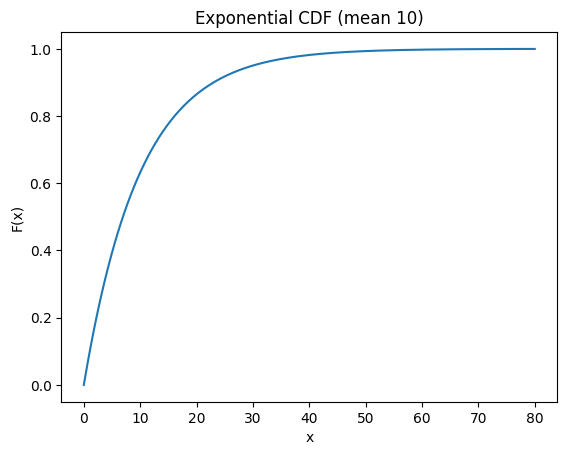

In [3]:

# random CDF and PDF
rv = stats.expon(scale=5)  # scale=mean=10
xs = np.linspace(0, 80, 400)

# Plots
plt.figure(); plt.plot(xs, rv.pdf(xs)); plt.title("Exponential PDF (mean 5)"); plt.xlabel("x"); plt.ylabel("f(x)"); plt.show()
plt.figure(); plt.plot(xs, rv.cdf(xs)); plt.title("Exponential CDF (mean 5)"); plt.xlabel("x"); plt.ylabel("F(x)"); plt.show()




The probability density function of the time customers arrive at a terminal (in minutes after 8:00 A.M.) is f(x)= $$e^{(-x/10)}/10$$ for 0 <x.

Determine the probability that

(a) The first customer arrives by 9:00 A.M.

(b) The first customer arrives between 8:15 A.M. and 8:30 A.M.

In [5]:
rv = stats.expon(scale=10)  # scale=mean=10
p_by_9am = rv.cdf(60)               # P(X <= 60)
p_15_30  = rv.cdf(30) - rv.cdf(15)  # P(15 <= X <= 30)



print(f"(a) P(X <= 60)  = {p_by_9am:.6f}")
print(f"(b) P(15<=X<=30)= {p_15_30:.6f}")

(a) P(X <= 60)  = 0.997521
(b) P(15<=X<=30)= 0.173343


**EXERCICE**

In a large corporate computer network, user log-ons to the system can be modeled as a Poisson process with a mean of 25 log-ons per hour. What is the probability that there are no log-ons in an interval of 6 minutes?

Let X denote the time in hours from the start of the interval until the first log-on. Then, X has an exponential distribution with λ=25 log-ons per hour

In [19]:
lam_per_hour = 25.0
mean = 1/lam_per_hour  # mean (in hours)
t_hours = 0.1                 # 6 minutes
#P(T > t) using 1 - CDF
p_gt_t = 1 - stats.expon.cdf(t_hours, scale=mean)

print(p_gt_t)

0.08208499862389884



## 3) Normal Distribution — theory

If $$X \sim \mathcal{N}(\mu, \sigma^2)$$:
- **PDF**: $$ f(x) = \dfrac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\dfrac{(x-\mu)^2}{2\sigma^2}\right) $$



**Tasks** Plot PDFs & CDFs for Different Normal Distributions

- Choose at least **three** parameter pairs $$(\mu, \sigma)$$.  
Suggested: \((0,1), (0,2), (2,1)\).
- Make a grid `xs` that covers all curves well.
- For each \((\mu,\sigma)\), create a SciPy normal `stats.norm(loc=mu, scale=sigma)` and plot its **PDF** on the same figure.
- Add a legend indicating the parameters.
- Observe: height at the mean, spread, and tails

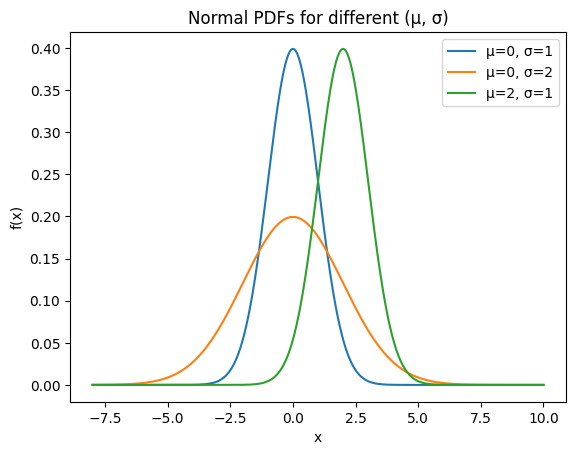

In [6]:
param_sets = [(0, 1), (0, 2), (2, 1)]  # (mu, sigma)

mu_vals = [p[0] for p in param_sets]
sigma_vals = [p[1] for p in param_sets]
x_min = min(mu_vals) - 4*max(sigma_vals)
x_max = max(mu_vals) + 4*max(sigma_vals)

xs = np.linspace(x_min, x_max, 800)

plt.figure()
for mu, sigma in param_sets:
    rv = stats.norm(loc=mu, scale=sigma)
    plt.plot(xs, rv.pdf(xs), label=f"μ={mu}, σ={sigma}")
plt.title("Normal PDFs for different (μ, σ)")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend()
plt.show()

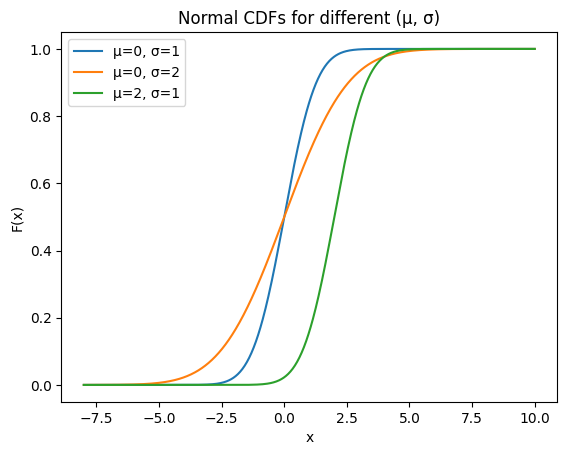

In [7]:
plt.figure()
for mu, sigma in param_sets:
    rv = stats.norm(loc=mu, scale=sigma)
    plt.plot(xs, rv.cdf(xs), label=f"μ={mu}, σ={sigma}")
plt.title("Normal CDFs for different (μ, σ)")
plt.xlabel("x"); plt.ylabel("F(x)")
plt.legend()
plt.show()


### Example — IQ Scores

Let \( X \) be IQ, modeled by  $$\mathcal{N}(100, 16²)$$.  

What is the probability that a randomly selected American has an IQ below 90?


In [9]:

mu = 100.0

p1 = stats.norm(loc=mu, scale=16.0).cdf(90)
print(f"Assuming variance=16 (sigma=16):  P(X<90) = {p1:.6f}")



Assuming variance=16 (sigma=4):  P(X<90) = 0.265986



### Example — Midterm Exam Cutoff.

Suppose X, the grade on a midterm exam, is normally distributed with mean 70 and standard deviation 10. The instructor wants to give 15% of the class an A.

What cutoff should the instructor use to determine who gets an A?

In [10]:

mu, sigma = 70.0, 10.0
z_85 = stats.norm.ppf(0.85)
cutoff = mu + sigma * z_85
print(f"z_0.85 = {z_85:.6f}")
print(f"Cutoff c = {cutoff:.4f}")


z_0.85 = 1.036433
Cutoff c = 80.3643



### Example — Emergency Department Length of Stay (Paris)

The length of stay at a specific emergency department in Paris, had a mean of 4.6 hours with a standard deviation of 2.9. Assume that the length of stay is normally distributed.

- What is the probability of a length of stay greater than 10 hours?

- What length of stay is exceeded by 25% of the visits?

- From the normally distributed model, what is the probability of a length of stay less than zero hours

In [11]:

mu, sigma = 4.6, 2.9
norm = stats.norm(loc=mu, scale=sigma)

p_gt_10 = 1.0 - norm.cdf(10)
x_75 = norm.ppf(0.75)
p_lt_0 = norm.cdf(0)

print(f"(1) P(X > 10) = {p_gt_10:.6f}")
print(f"(2) 75th percentile = {x_75:.4f} hours")
print(f"(3) P(X < 0) = {p_lt_0:.6f}")


(1) P(X > 10) = 0.031297
(2) 75th percentile = 6.5560 hours
(3) P(X < 0) = 0.056346
